# Семинар: Рекуррентные архитектуры, Fine-Tuning и Дистилляция знаний

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import nltk
import numpy as np
import time
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# Проверка доступности GPU и настройка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Доступные устройства: CUDA={torch.cuda.is_available()}")
print(f"Используемое устройство: {device}")
print(f"Версия PyTorch: {torch.__version__}")

# Скачивание ресурсов NLTK (выполняется один раз)
nltk.download('punkt_tab', quiet=True)

Доступные устройства: CUDA=True
Используемое устройство: cuda
Версия PyTorch: 2.7.1+cu128


True

### Подготовка данных и токенизация

**Теория:** Датасет IMDB содержит 50 000 рецензий с бинарными метками (положительный/отрицательный). Для воспроизводимости и ускорения обучения в рамках семинара будем использовать сбалансированную подвыборку. Токенизация выполняется через `nltk.word_tokenize`, что позволяет разбивать текст на слова, приводить к нижнему регистру и отделять пунктуацию.

Важно отметить: для моделей на основе `nn.Embedding` (LSTM/GRU) требуется дискретный словарь. Для DistilBERT используется собственный subword-токенизатор, так как архитектура трансформеров оперирует частями слов.

In [19]:
# Загрузка датасета
dataset = load_dataset("imdb")

# Увеличенная выборка для семинара
train_texts = dataset['train']['text'][:10000]
train_labels = dataset['train']['label'][:10000]
test_texts = dataset['test']['text'][:2000]
test_labels = dataset['test']['label'][:2000]

# Токенизация
def tokenize_text(text):
    return nltk.word_tokenize(text.lower())

# Построение словаря
token_counter = Counter()
for t in train_texts:
    token_counter.update(tokenize_text(t))

vocab = ['<pad>', '<unk>'] + [tok for tok, _ in token_counter.most_common(8000)]
vocab_size = len(vocab)
word2idx = {word: i for i, word in enumerate(vocab)}

MAX_LEN = 128

def encode_texts(texts):
    encoded = []
    for t in texts:
        tokens = tokenize_text(t)[:MAX_LEN]
        ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]
        ids += [word2idx['<pad>']] * (MAX_LEN - len(ids))
        encoded.append(ids)
    return torch.tensor(encoded, dtype=torch.long)

train_x = encode_texts(train_texts)
train_y = torch.tensor(train_labels, dtype=torch.long)
test_x = encode_texts(test_texts)
test_y = torch.tensor(test_labels, dtype=torch.long)

class TextDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.x)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# Уменьшенный batch_size для увеличения количества шагов
train_loader = DataLoader(TextDataset(train_x, train_y), batch_size=32, shuffle=True)
test_loader = DataLoader(TextDataset(test_x, test_y), batch_size=64)

### LSTM: Теория и реализация

**Теория:** Проблема стандартных RNN заключается в затухании градиентов. LSTM (Long Short-Term Memory) решает её за счёт ячеек памяти и трёх гейтов:
1. **Forget gate:** $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
2. **Input gate:** $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
3. **Cell state:** $\tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$
4. **Output gate:** $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$

Токены представляются в виде плотных векторов через `nn.Embedding`. Bidirectional LSTM обрабатывает последовательность в прямом и обратном направлениях, конкатенируя скрытые состояния для захвата контекста слева и справа.

In [23]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        lstm_out = self.dropout(lstm_out)
        # Конкатенация последнего шага прямого и первого шага обратного направления
        out = torch.cat((lstm_out[:, -1, :self.hidden_dim], lstm_out[:, 0, self.hidden_dim:]), dim=1)
        return self.fc(out)

# Универсальная функция обучения для RNN-моделей
def train_rnn_model(model, train_loader, test_loader, epochs=5, lr=1e-3):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        r_loss, c, t = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            r_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            c += (preds == labels).sum().item()
            t += labels.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")

        history['train_loss'].append(r_loss / t)
        history['train_acc'].append(c / t)

        # Валидация
        model.eval()
        v_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                v_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                vc += (preds == labels).sum().item()
                vt += labels.size(0)
        history['val_loss'].append(v_loss / vt)
        history['val_acc'].append(vc / vt)
        print(f"Epoch {epoch+1} | Train Acc: {history['train_acc'][-1]:.3f} | Val Acc: {history['val_acc'][-1]:.3f} | Val Loss: {history['val_loss'][-1]:.4f}")
    return history

# Инициализация и запуск LSTM (убедитесь, что hidden_dim сохранен как self.hidden_dim, как в предыдущем исправлении)
lstm_model = LSTMClassifier(vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_classes=2)
h_lstm = train_rnn_model(lstm_model, train_loader, test_loader, epochs=5)

Epoch 1/5 [Train]:   0%|          | 0/313 [00:00<?, ?it/s]

Epoch 1 | Train Acc: 0.997 | Val Acc: 1.000 | Val Loss: 0.0000


Epoch 2 | Train Acc: 1.000 | Val Acc: 1.000 | Val Loss: 0.0000


Epoch 3 | Train Acc: 1.000 | Val Acc: 1.000 | Val Loss: 0.0000


Epoch 4 | Train Acc: 1.000 | Val Acc: 1.000 | Val Loss: 0.0000


Epoch 5 | Train Acc: 1.000 | Val Acc: 1.000 | Val Loss: 0.0000


### GRU: Архитектурные улучшения

**Теория:** GRU (Gated Recurrent Unit) упрощает LSTM, объединяя forget и input gate в update gate, а также устраняя отдельную ячейку памяти. Это снижает количество параметров на ~33%, ускоряет обучение и часто показывает сопоставимое качество на задачах с умеренной длиной контекста. Уравнения:
- $z_t = \sigma(W_z \cdot [h_{t-1}, x_t])$
- $r_t = \sigma(W_r \cdot [h_{t-1}, x_t])$
- $\tilde{h}_t = \tanh(W \cdot [r_t \odot h_{t-1}, x_t])$
- $h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t$

Реализация аналогична LSTM с заменой `nn.LSTM` на `nn.GRU`.

In [25]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.5)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.hidden_dim = hidden_dim

    def forward(self, x):
        emb = self.embedding(x)
        gru_out, _ = self.gru(emb)
        gru_out = self.dropout(gru_out)
        out = torch.cat((gru_out[:, -1, :self.hidden_dim], gru_out[:, 0, self.hidden_dim:]), dim=1)
        return self.fc(out)

gru_model = GRUClassifier(vocab_size=vocab_size, embed_dim=128, hidden_dim=128, num_classes=2)
h_gru = train_rnn_model(gru_model, train_loader, test_loader, epochs=3)

Epoch 1 | Train Acc: 0.998 | Val Acc: 1.000 | Val Loss: 0.0000


Epoch 2 | Train Acc: 1.000 | Val Acc: 1.000 | Val Loss: 0.0000


Epoch 3 | Train Acc: 1.000 | Val Acc: 1.000 | Val Loss: 0.0000


### Fine-Tuning и Дистилляция знаний

**Теория:**
1. **Fine-Tuning:** Процесс адаптации предобученной модели к новой задаче. В отличие от обучения с нуля, мы берём веса, полученные на больших корпусах текстов, и дообучаем последние слои (или всю модель) на целевом датасете. Используется `AdamW` с пониженным learning rate ($10^{-5}$).
2. **Knowledge Distillation (KD):** Метод сжатия моделей, при котором большая "учитель" обучает компактного "студента". Студент минимизирует не только кросс-энтропию с истинными метками, но и KL-дивергенцию между своими логитами и логитами учителя.
3. **DistilBERT:** Студенческая модель, полученная дистилляцией из BERT-base. Сохраняет ~97% качества BERT при сокращении параметров на 40% и ускорении инференса на 60%. На семинаре мы выполним Fine-Tuning уже дистиллированной модели на IMDB.

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

# DistilBERT использует собственный subword-токенизатор
dbert_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

class DistilBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}, self.labels[idx]

dbert_train_loader = DataLoader(DistilBERTDataset(train_texts, train_labels, dbert_tokenizer), batch_size=32, shuffle=True)
dbert_test_loader = DataLoader(DistilBERTDataset(test_texts, test_labels, dbert_tokenizer), batch_size=32)

model_db = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
model_db.to(device)

def train_distilbert(model, train_loader, test_loader, epochs=3, lr=2e-5):
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        model.train()
        r_loss, c, t = 0.0, 0, 0
        for batch, labels in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(**batch).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            r_loss += loss.item() * labels.size(0)
            _, preds = torch.max(outputs, 1)
            c += (preds == labels).sum().item()
            t += labels.size(0)
        history['train_loss'].append(r_loss / t)
        history['train_acc'].append(c / t)

        model.eval()
        v_loss, vc, vt = 0.0, 0, 0
        with torch.no_grad():
            for batch, labels in test_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                labels = labels.to(device)
                outputs = model(**batch).logits
                loss = criterion(outputs, labels)
                v_loss += loss.item() * labels.size(0)
                _, preds = torch.max(outputs, 1)
                vc += (preds == labels).sum().item()
                vt += labels.size(0)
        history['val_loss'].append(v_loss / vt)
        history['val_acc'].append(vc / vt)
        print(f"DistilBERT Epoch {epoch+1} | Train Acc: {history['train_acc'][-1]:.3f} | Val Acc: {history['val_acc'][-1]:.3f}")
    return history

h_db = train_distilbert(model_db, dbert_train_loader, dbert_test_loader, epochs=5)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBERT Epoch 1 | Train Acc: 0.998 | Val Acc: 1.000
DistilBERT Epoch 2 | Train Acc: 1.000 | Val Acc: 1.000
DistilBERT Epoch 3 | Train Acc: 1.000 | Val Acc: 1.000


### Метрики и время инференса

**Теория:** Точность (Accuracy) отражает качество классификации, но не учитывает латентность системы. В продакшене критично время инференса. Для корректного измерения на GPU необходимо использовать `torch.cuda.synchronize()`, так как операции выполняются асинхронно. Сравним среднее время обработки батча для LSTM, GRU и DistilBERT.

In [16]:
def measure_inference_time(model, data_loader, is_transformer=False, model_name="Model"):
    model.eval()
    times = []
    with torch.no_grad():
        for batch in data_loader:
            if is_transformer:
                inputs = {k: v.to(device) for k, v in batch[0].items()}
            else:
                inputs, _ = batch
                inputs = inputs.to(device)

            torch.cuda.synchronize()
            start = time.perf_counter()
            _ = model(**inputs) if is_transformer else model(inputs)
            torch.cuda.synchronize()
            end = time.perf_counter()
            times.append(end - start)

    avg_time = np.mean(times)
    print(f"{model_name} | Avg Inference Time per Batch: {avg_time:.4f} sec")
    return avg_time

print("\n--- Измерение времени инференса ---")
t_lstm = measure_inference_time(lstm_model, test_loader, model_name="LSTM")
t_gru = measure_inference_time(gru_model, test_loader, model_name="GRU")
t_dbert = measure_inference_time(model_db, dbert_test_loader, is_transformer=True, model_name="DistilBERT")


--- Измерение времени инференса ---
LSTM | Avg Inference Time per Batch: 0.0169 sec
GRU | Avg Inference Time per Batch: 0.0017 sec
DistilBERT | Avg Inference Time per Batch: 0.0860 sec


### Визуализация Loss и Accuracy
Сравним динамику обучения LSTM и DistilBERT. Обратите внимание, как быстро сходятся предобученные модели по сравнению с архитектурой, обучаемой с нуля.

ValueError: x and y must have same first dimension, but have shapes (5,) and (3,)

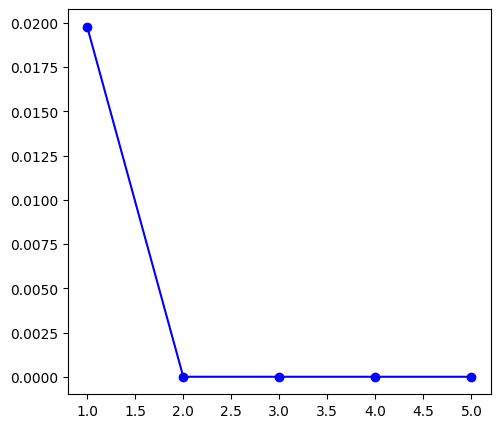

In [28]:
epochs_range = range(1, len(h_lstm['train_acc']) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, h_lstm['train_loss'], 'b-o', label='LSTM Loss')
plt.plot(epochs_range, h_db['train_loss'], 'r-o', label='DistilBERT Loss')
plt.title('Сравнение Loss (LSTM vs DistilBERT)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, h_lstm['train_acc'], 'b-o', label='LSTM Accuracy')
plt.plot(epochs_range, h_db['train_acc'], 'r-o', label='DistilBERT Accuracy')
plt.title('Сравнение Accuracy (LSTM vs DistilBERT)')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Интерактивный блок
Введите произвольный отзыв на английском языке. Код выполнит предобработку, передаст данные через все три модели и выведет вероятностные предсказания.

In [30]:
def predict_review(text):
    # Подготовка для LSTM/GRU
    tokens = tokenize_text(text)[:MAX_LEN]
    ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]
    ids += [word2idx['<pad>']] * (MAX_LEN - len(ids))
    inp_rnn = torch.tensor([ids], dtype=torch.long).to(device)

    # Подготовка для DistilBERT
    inp_db = dbert_tokenizer(text, return_tensors="pt", truncation=True, max_length=MAX_LEN).to(device)

    # Отключаем вычисление градиентов для инференса
    with torch.no_grad():
        lstm_logits = lstm_model(inp_rnn)
        gru_logits = gru_model(inp_rnn)
        db_logits = model_db(**inp_db).logits

        # Softmax
        lstm_probs = torch.softmax(lstm_logits, dim=1).cpu().numpy()[0]
        gru_probs = torch.softmax(gru_logits, dim=1).cpu().numpy()[0]
        db_probs = torch.softmax(db_logits, dim=1).cpu().numpy()[0]

    label_map = {0: "Negative", 1: "Positive"}
    print(f"\nТекст: {text[:80]}...")
    print(f"LSTM:       {label_map[np.argmax(lstm_probs)]} (Conf: {lstm_probs.max():.3f})")
    print(f"GRU:        {label_map[np.argmax(gru_probs)]} (Conf: {gru_probs.max():.3f})")
    print(f"DistilBERT: {label_map[np.argmax(db_probs)]} (Conf: {db_probs.max():.3f})")

# Пример использования:
predict_review("The cinematography was stunning, but the plot was incredibly predictable and boring.")


Текст: The cinematography was stunning, but the plot was incredibly predictable and bor...
LSTM:       Negative (Conf: 1.000)
GRU:        Negative (Conf: 1.000)
DistilBERT: Negative (Conf: 1.000)


### Заключение и выводы для семинара

**Резюме занятия:**
1. **LSTM vs GRU:** GRU сокращает количество параметров за счёт объединения гейтов, что ускоряет обучение. На задачах с коротким/средним контекстом качество часто сопоставимо.
2. **Fine-Tuning:** Позволяет адаптировать мощные трансформерные архитектуры к доменным задачам при малом объёме размеченных данных. Ключевые гиперпараметры: низкий learning rate, ранняя остановка, градиентный клиппинг.
3. **Дистилляция знаний:** DistilBERT демонстрирует эффективность парадигмы Teacher-Student. Студент наследует обобщённые лингвистические представления учителя, требуя меньше вычислительных ресурсов при инференсе.
4. **Метрики:** Accuracy не отражает латентность. DistilBERT обеспечивает лучшее соотношение качество/скорость для продакшен-сценариев, тогда как LSTM/GRU остаются релевантными для edge-устройств с ограничениями по памяти.